In [5]:
import ee
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize Earth Engine
try:
    ee.Initialize(project="gee-xplore")
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project="gee-xplore")

# 2. Define Point of Interest (Bhandara, MH)
poi_lon, poi_lat = 79.65, 21.17 
poi = ee.Geometry.Point([poi_lon, poi_lat])
start_date, end_date = '2023-06-01', '2023-12-31'

# 3. Filter Sentinel-1 Archive (CRITICAL: Added DESCENDING orbit filter)
s1_collection = (ee.ImageCollection('COPERNICUS/S1_GRD')
                 .filterBounds(poi)
                 .filterDate(start_date, end_date)
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
                 .filter(ee.Filter.eq('instrumentMode', 'IW'))
                 .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')) # The Fix
                 .select('VH'))

# 4. Extract Point Data
def extract_point_data(image):
    date = image.date().format('YYYY-MM-dd')
    value = image.reduceRegion(reducer=ee.Reducer.first(), geometry=poi, scale=10).get('VH')
    return ee.Feature(None, {'date': date, 'VH': value})

ts_features = s1_collection.map(extract_point_data).getInfo()

# 5. Format to DataFrame & Sanity Check
data = [f['properties'] for f in ts_features['features']]
df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])
df = df.dropna().sort_values('date').reset_index(drop=True)

# Note: VH values are in decibels (log scale). 
# Smoothing operates on this log-transformed data.
print(f"Extraction complete. Valid observations: {len(df)}")
if len(df) < 15:
    print("WARNING: Time series is too sparse for reliable smoothing.")

Extraction complete. Valid observations: 18


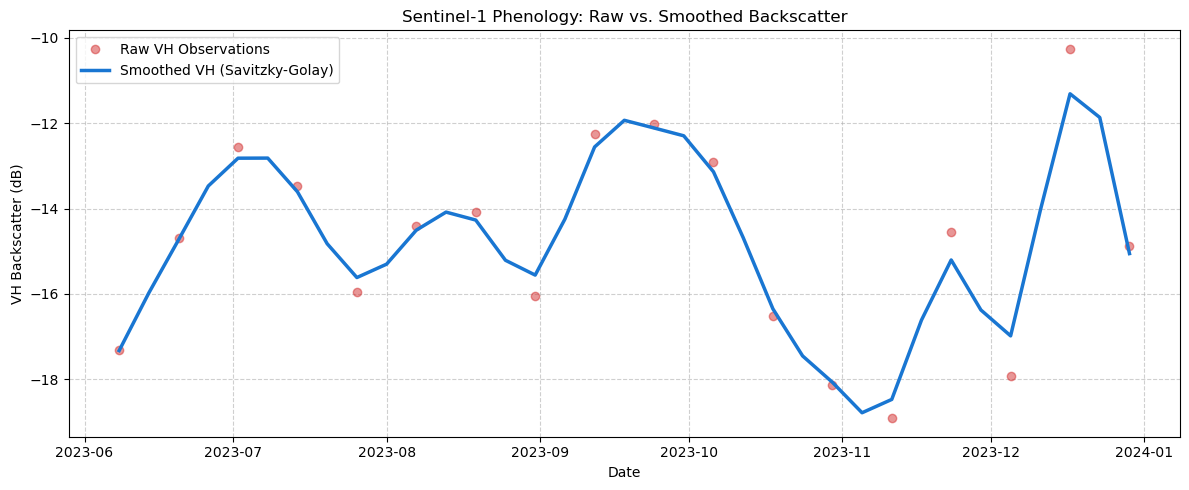

In [6]:
from scipy.signal import savgol_filter

# 1. Resample to a regular 6-day grid (Without mutating the original df)
# We chain set_index directly into resample so the original df stays intact
df_resampled = df.set_index('date').resample('6D').mean() 
df_resampled['VH'] = df_resampled['VH'].interpolate(method='linear') # Fill gaps
df_resampled.reset_index(inplace=True)

# 2. Savitzky-Golay parameters
# A window length of 5 on a 6-day grid covers ~1 month of data context
window_length = 5   # Must be odd
polyorder = 2       # Degree of polynomial

# 3. Apply smoothing
df_resampled['VH_smooth'] = savgol_filter(
    df_resampled['VH'], 
    window_length=window_length, 
    polyorder=polyorder
)

# 4. Visual Comparison
plt.figure(figsize=(12, 5))

# Raw, irregular signal (df now still has its 'date' column!)
plt.plot(df['date'], df['VH'], 
         marker='o', linestyle='', # Removed line to highlight raw points
         color='#d32f2f', alpha=0.5, label='Raw VH Observations')

# Smoothed, regularized signal
plt.plot(df_resampled['date'], df_resampled['VH_smooth'], 
         linestyle='-', linewidth=2.5, 
         color='#1976d2', label='Smoothed VH (Savitzky-Golay)')

plt.title('Sentinel-1 Phenology: Raw vs. Smoothed Backscatter')
plt.ylabel('VH Backscatter (dB)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

✅ Estimated Transplanting Date: 2023-11-05


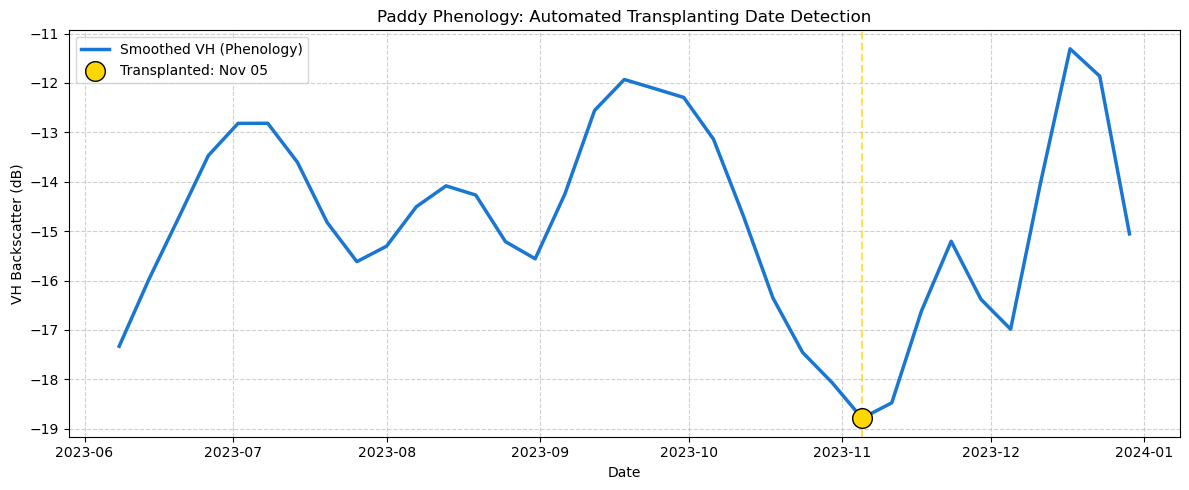

In [7]:
# 1. Find the index of the minimum value in the smoothed curve
min_idx = df_resampled['VH_smooth'].idxmin()

# 2. Extract the exact date and value
transplant_date = df_resampled.loc[min_idx, 'date']
transplant_vh = df_resampled.loc[min_idx, 'VH_smooth']

print(f"✅ Estimated Transplanting Date: {transplant_date.strftime('%Y-%m-%d')}")

# 3. Visualize the insight
plt.figure(figsize=(12, 5))

# Plot the smoothed signal
plt.plot(df_resampled['date'], df_resampled['VH_smooth'], 
         linestyle='-', linewidth=2.5, color='#1976d2', label='Smoothed VH (Phenology)')

# Highlight the transplanting date with a massive gold marker
plt.scatter(transplant_date, transplant_vh, 
            color='gold', s=200, zorder=5, edgecolors='black', 
            label=f"Transplanted: {transplant_date.strftime('%b %d')}")

# Draw a vertical drop-line to the x-axis for emphasis
plt.axvline(x=transplant_date, color='gold', linestyle='--', alpha=0.7)

plt.title('Paddy Phenology: Automated Transplanting Date Detection')
plt.ylabel('VH Backscatter (dB)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

✅ Verified Kharif Transplanting Date: 2023-08-13


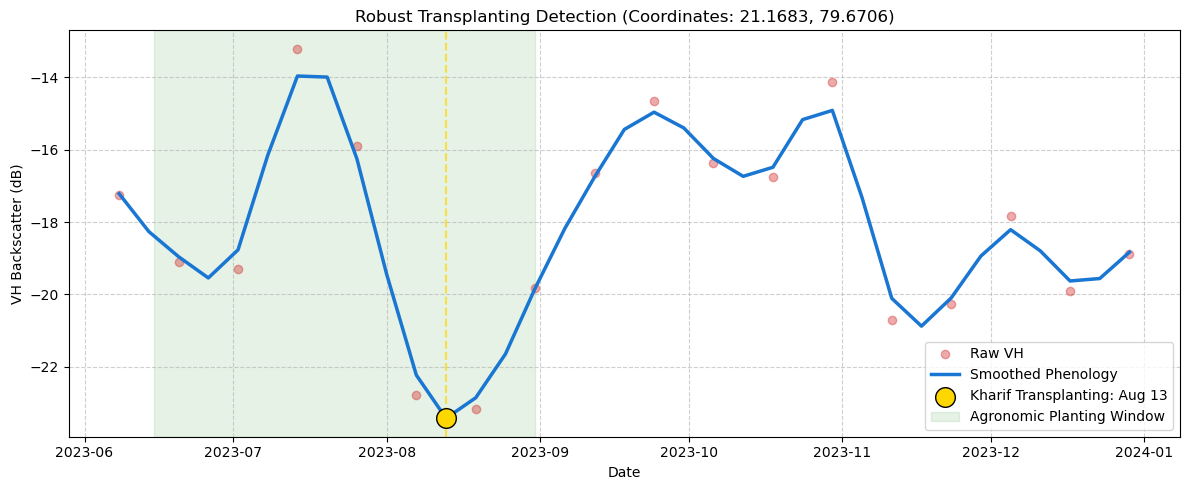

In [9]:
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

# 1. Initialize & Define the PURE Paddy Field Coordinate
ee.Initialize(project="gee-xplore")
poi_lon, poi_lat = 79.67055221515592, 21.16831593650651
poi = ee.Geometry.Point([poi_lon, poi_lat])
start_date, end_date = '2023-06-01', '2023-12-31'

# 2. Extract Sentinel-1 (Descending, VH)
s1_collection = (ee.ImageCollection('COPERNICUS/S1_GRD')
                 .filterBounds(poi).filterDate(start_date, end_date)
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
                 .filter(ee.Filter.eq('instrumentMode', 'IW'))
                 .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
                 .select('VH'))

def extract_point_data(image):
    date = image.date().format('YYYY-MM-dd')
    value = image.reduceRegion(reducer=ee.Reducer.first(), geometry=poi, scale=10).get('VH')
    return ee.Feature(None, {'date': date, 'VH': value})

ts_features = s1_collection.map(extract_point_data).getInfo()
df = pd.DataFrame([f['properties'] for f in ts_features['features']])
df['date'] = pd.to_datetime(df['date'])
df = df.dropna().sort_values('date').reset_index(drop=True)

# 3. Resample and Smooth (Savitzky-Golay)
df_resampled = df.set_index('date').resample('6D').mean()
df_resampled['VH'] = df_resampled['VH'].interpolate(method='linear')
df_resampled.reset_index(inplace=True)
df_resampled['VH_smooth'] = savgol_filter(df_resampled['VH'], window_length=5, polyorder=2)

# 4. The GeoAI Logic: Kharif Local Minimum Detection
# We invert the signal because find_peaks looks for HIGHEST points
inverted_signal = -df_resampled['VH_smooth']
peaks, _ = find_peaks(inverted_signal)

# Filter the found minimums to ONLY those inside the Kharif planting window
kharif_start, kharif_end = pd.to_datetime('2023-06-15'), pd.to_datetime('2023-08-31')
valid_transplant_dates = []

for peak_idx in peaks:
    peak_date = df_resampled.loc[peak_idx, 'date']
    if kharif_start <= peak_date <= kharif_end:
        valid_transplant_dates.append((peak_date, df_resampled.loc[peak_idx, 'VH_smooth']))

# 5. Visualize the correct insight
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['VH'], marker='o', linestyle='', color='#d32f2f', alpha=0.4, label='Raw VH')
plt.plot(df_resampled['date'], df_resampled['VH_smooth'], linestyle='-', linewidth=2.5, color='#1976d2', label='Smoothed Phenology')

if valid_transplant_dates:
    # Take the deepest dip within the valid window
    best_transplant = min(valid_transplant_dates, key=lambda x: x[1])
    t_date, t_val = best_transplant
    plt.scatter(t_date, t_val, color='gold', s=200, zorder=5, edgecolors='black', label=f"Kharif Transplanting: {t_date.strftime('%b %d')}")
    plt.axvline(x=t_date, color='gold', linestyle='--', alpha=0.7)
    # Highlight the valid agronomic window
    plt.axvspan(kharif_start, kharif_end, color='green', alpha=0.1, label='Agronomic Planting Window')
    print(f"✅ Verified Kharif Transplanting Date: {t_date.strftime('%Y-%m-%d')}")
else:
    print("❌ No valid transplanting signature found in the Kharif window.")

plt.title(f'Robust Transplanting Detection (Coordinates: {poi_lat:.4f}, {poi_lon:.4f})')
plt.ylabel('VH Backscatter (dB)')
plt.xlabel('Date')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()